# U.S. Federal Awards Portfolio Analysis — FY2026

## DATA INPUT
This project analyzes **FY2026** U.S. federal prime award summaries from USAspending for the Department of Education, Department of Transportation, and Department of Housing and Urban Development.

The analysis uses two source files:
- Contracts — Prime Award Summaries
- Financial Assistance — Prime Award Summaries

## Check the Award Date Range

I check the earliest and latest base action dates in both datasets to confirm that the awards fall within FY2026.

The U.S. federal fiscal year is different from the calendar year. FY2026 begins on October 1, 2025 and ends on September 30, 2026. Therefore, awards with base action dates in late 2025 can still be part of FY2026.

The contracts dataset covers FY2026 awards from October 1, 2025 to September 15, 2026, while the financial assistance dataset covers awards from October 16, 2025 to September 18, 2026.


## 1. Import Packages

I first import the Python packages that will be used for data cleaning, analysis, and visualization.

In [1]:
import sys
print(sys.version)

3.12.2 (v3.12.2:6abddd9f6a, Feb  6 2024, 17:02:06) [Clang 13.0.0 (clang-1300.0.29.30)]


## 2. Load the Contracts Dataset

The first dataset contains federal contract award summaries from USAspending. I load the dataset and check its number of rows and columns.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

contracts = pd.read_csv("Contracts_PrimeAwardSummaries.csv")
print("Rows:", contracts.shape[0])
print("Columns:", contracts.shape[1])

Rows: 36427
Columns: 286


/var/folders/3q/nr7prv0n6_126gxj0ftcpdgh0000gn/T/ipykernel_69363/3689496905.py:4: DtypeWarning: Columns (2: parent_award_agency_id, 31: funding_sub_agency_code, 38: program_activities_funding_this_award, 42: sam_exception_description, 63: recipient_zip_4_code, 66: recipient_phone_number, 67: recipient_fax_number, 76: primary_place_of_performance_zip_4, 109: information_technology_commercial_item_category_code, 110: information_technology_commercial_item_category, 127: research_code, 128: research, 156: other_statutory_authority, 163: national_interest_action_code, 164: national_interest_action, 171: sea_transportation_code, 172: sea_transportation) have mixed types. Specify dtype option on import or set low_memory=False.
  contracts = pd.read_csv("Contracts_PrimeAwardSummaries.csv")


In [3]:
contracts.head()

,contract_award_unique_key,award_id_piid,parent_award_agency_id,parent_award_agency_name,parent_award_id_piid,disaster_emergency_fund_codes,outlayed_amount_from_COVID-19_supplementals,obligated_amount_from_COVID-19_supplementals,outlayed_amount_from_IIJA_supplemental,obligated_amount_from_IIJA_supplemental,...,highly_compensated_officer_2_name,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,last_modified_date
0,CONT_AWD_00001_8600_DU100G16D01_8600,00001,8600,"HOUSING AND URBAN DEVELOPMENT, DEPARTMENT OF",DU100G16D01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_000...,2025-11-17 06:30:10+00
1,CONT_AWD_00002_8600_DU100G16D01_8600,00002,8600,"HOUSING AND URBAN DEVELOPMENT, DEPARTMENT OF",DU100G16D01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_000...,2025-11-17 06:33:07+00
2,CONT_AWD_00003_8600_DU100G16D01_8600,00003,8600,"HOUSING AND URBAN DEVELOPMENT, DEPARTMENT OF",DU100G16D01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_000...,2026-03-03 10:54:14+00
3,CONT_AWD_00005_6901_DTRT5717D30006_6901,00005,6901,OFFICE OF THE SECRETARY,DTRT5717D30006,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_000...,2025-05-12 17:50:37+00
4,CONT_AWD_0001_6901_DTRT5715D30011_6901,0001,6901,OFFICE OF THE SECRETARY,DTRT5715D30011,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,...,MICHAEL H MUSIMI,852431.0,ROBERT D BRAUN,921093.0,TIMOTHY J GALPIN,860512.0,JAMES N MILLER,819498.0,https://www.usaspending.gov/award/CONT_AWD_000...,2025-02-27 09:22:00+00


## 3. Explore the Contracts Dataset

Before cleaning the data, I examine the column names and basic information about the dataset. This helps identify which variables are useful for the analysis.

In [4]:
contracts.info()

<class 'pandas.DataFrame'>
RangeIndex: 36427 entries, 0 to 36426
Columns: 286 entries, contract_award_unique_key to last_modified_date
dtypes: float64(35), int64(6), object(6), str(239)
memory usage: 79.5+ MB


In [5]:
print(contracts.columns.tolist())

['contract_award_unique_key', 'award_id_piid', 'parent_award_agency_id', 'parent_award_agency_name', 'parent_award_id_piid', 'disaster_emergency_fund_codes', 'outlayed_amount_from_COVID-19_supplementals', 'obligated_amount_from_COVID-19_supplementals', 'outlayed_amount_from_IIJA_supplemental', 'obligated_amount_from_IIJA_supplemental', 'total_obligated_amount', 'total_outlayed_amount', 'current_total_value_of_award', 'potential_total_value_of_award', 'award_base_action_date', 'award_base_action_date_fiscal_year', 'award_latest_action_date', 'award_latest_action_date_fiscal_year', 'period_of_performance_start_date', 'period_of_performance_current_end_date', 'period_of_performance_potential_end_date', 'ordering_period_end_date', 'solicitation_date', 'awarding_agency_code', 'awarding_agency_name', 'awarding_sub_agency_code', 'awarding_sub_agency_name', 'awarding_office_code', 'awarding_office_name', 'funding_agency_code', 'funding_agency_name', 'funding_sub_agency_code', 'funding_sub_agen

## 4. Load the Financial Assistance Dataset

The second dataset contains federal financial assistance award summaries from USAspending.

One row in the CSV has a different number of fields from the rest of the file. I identify the formatting issue and then use the Python parsing engine to load the usable records while displaying a warning for the row that cannot be parsed correctly.


In [6]:
import csv

with open("Assistance_PrimeAwardSummaries.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)

    for line_number, row in enumerate(reader, start=1):
        if len(row) != 100:
            print("Problem line:", line_number)
            print("Number of fields:", len(row))

Problem line: 211
Number of fields: 158


In [7]:
assistance = pd.read_csv("Assistance_PrimeAwardSummaries.csv",engine="python",on_bad_lines="warn")
print("Rows:", assistance.shape[0])
print("Columns:", assistance.shape[1])

/var/folders/3q/nr7prv0n6_126gxj0ftcpdgh0000gn/T/ipykernel_69363/1430438956.py:1: ParserWarning: Skipping line 211: Expected 100 fields in line 211, saw 158

  assistance = pd.read_csv("Assistance_PrimeAwardSummaries.csv",engine="python",on_bad_lines="warn")


Rows: 54131
Columns: 100


In [8]:
assistance.head()

,assistance_award_unique_key,award_id_fain,award_id_uri,sai_number,disaster_emergency_fund_codes,outlayed_amount_from_COVID-19_supplementals,obligated_amount_from_COVID-19_supplementals,outlayed_amount_from_IIJA_supplemental,obligated_amount_from_IIJA_supplemental,award_latest_action_date,...,highly_compensated_officer_2_name,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,last_modified_date
0,ASST_NON_470253004LZ2E_069,470253004LZ2E,470253004LZ2E00418707,SAI EXEMPT,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,2025-02-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_470...,2025-02-19 16:31:56.391706+00
1,ASST_NON_470255014L23E_069,470255014L23E,470255014L23E00303705,SAI EXEMPT,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,2024-03-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_470...,2024-04-02 22:29:40.924224+00
2,ASST_NON_470266021Z231_069,470266021Z231,470266021Z23100599990,SAI EXEMPT,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,2024-05-29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_470...,2024-06-10 15:45:11.664915+00
3,ASST_NON_470269017LY50_069,470269017LY50,470269017LY5000504708,SAI EXEMPT,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,2024-06-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_470...,2024-06-24 15:50:26.970138+00
4,ASST_NON_470269020L050_069,470269020L050,470269020L05000615709,SAI EXEMPT,Q: Not Designated Nonemergency/Emergency/Disas...,NaN,NaN,NaN,NaN,2026-06-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_470...,2026-07-06 20:55:11.046823+00


## 5. Explore the Financial Assistance Dataset

I also examine the structure of the financial assistance dataset before selecting the variables needed for the analysis.

In [9]:
assistance.info()

<class 'pandas.DataFrame'>
RangeIndex: 54131 entries, 0 to 54130
Data columns (total 100 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   assistance_award_unique_key                                54131 non-null  str    
 1   award_id_fain                                              54131 non-null  str    
 2   award_id_uri                                               27430 non-null  str    
 3   sai_number                                                 30594 non-null  str    
 4   disaster_emergency_fund_codes                              42744 non-null  str    
 5   outlayed_amount_from_COVID-19_supplementals                11 non-null     float64
 6   obligated_amount_from_COVID-19_supplementals               20 non-null     float64
 7   outlayed_amount_from_IIJA_supplemental                     13320 non-null  float64
 8   obligated_amount

In [10]:
print(assistance.columns.tolist())

['assistance_award_unique_key', 'award_id_fain', 'award_id_uri', 'sai_number', 'disaster_emergency_fund_codes', 'outlayed_amount_from_COVID-19_supplementals', 'obligated_amount_from_COVID-19_supplementals', 'outlayed_amount_from_IIJA_supplemental', 'obligated_amount_from_IIJA_supplemental', 'award_latest_action_date', 'award_latest_action_date_fiscal_year', 'total_obligated_amount', 'total_outlayed_amount', 'indirect_cost_federal_share_amount', 'total_non_federal_funding_amount', 'total_funding_amount', 'total_face_value_of_loan', 'total_loan_subsidy_cost', 'award_base_action_date', 'award_base_action_date_fiscal_year', 'period_of_performance_start_date', 'period_of_performance_current_end_date', 'awarding_agency_code', 'awarding_agency_name', 'awarding_sub_agency_code', 'awarding_sub_agency_name', 'awarding_office_code', 'awarding_office_name', 'funding_agency_code', 'funding_agency_name', 'funding_sub_agency_code', 'funding_sub_agency_name', 'funding_office_code', 'funding_office_nam

## 6. Identify Variables for the Analysis

The original USAspending datasets contain many variables that are not necessary for this project. I focus on variables related to the award, agency, recipient, location, fiscal year, program, obligations, and outlays.

In [11]:
keywords = [
    "award",
    "agency",
    "recipient",
    "state",
    "action",
    "oblig",
    "outlay",
    "naics"
]
for column in contracts.columns:
    if any(keyword in column.lower() for keyword in keywords):
        print(column)

contract_award_unique_key
award_id_piid
parent_award_agency_id
parent_award_agency_name
parent_award_id_piid
outlayed_amount_from_COVID-19_supplementals
obligated_amount_from_COVID-19_supplementals
outlayed_amount_from_IIJA_supplemental
obligated_amount_from_IIJA_supplemental
total_obligated_amount
total_outlayed_amount
current_total_value_of_award
potential_total_value_of_award
award_base_action_date
award_base_action_date_fiscal_year
award_latest_action_date
award_latest_action_date_fiscal_year
awarding_agency_code
awarding_agency_name
awarding_sub_agency_code
awarding_sub_agency_name
awarding_office_code
awarding_office_name
funding_agency_code
funding_agency_name
funding_sub_agency_code
funding_sub_agency_name
treasury_accounts_funding_this_award
federal_accounts_funding_this_award
object_classes_funding_this_award
program_activities_funding_this_award
recipient_uei
recipient_duns
recipient_name
recipient_name_raw
recipient_doing_business_as_name
recipient_parent_uei
recipient_pare

In [12]:
keywords = [
    "award",
    "agency",
    "recipient",
    "state",
    "action",
    "oblig",
    "outlay",
    "cfda",
    "assistance"
]

for column in assistance.columns:
    if any(keyword in column.lower() for keyword in keywords):
        print(column)

assistance_award_unique_key
award_id_fain
award_id_uri
outlayed_amount_from_COVID-19_supplementals
obligated_amount_from_COVID-19_supplementals
outlayed_amount_from_IIJA_supplemental
obligated_amount_from_IIJA_supplemental
award_latest_action_date
award_latest_action_date_fiscal_year
total_obligated_amount
total_outlayed_amount
award_base_action_date
award_base_action_date_fiscal_year
awarding_agency_code
awarding_agency_name
awarding_sub_agency_code
awarding_sub_agency_name
awarding_office_code
awarding_office_name
funding_agency_code
funding_agency_name
funding_sub_agency_code
funding_sub_agency_name
treasury_accounts_funding_this_award
federal_accounts_funding_this_award
object_classes_funding_this_award
program_activities_funding_this_award
recipient_uei
recipient_duns
recipient_name
recipient_name_raw
recipient_parent_uei
recipient_parent_duns
recipient_parent_name
recipient_country_code
recipient_country_name
recipient_address_line_1
recipient_address_line_2
recipient_city_code
r

## 7. Create Working Copies

I create separate copies of the original datasets before cleaning the data. This keeps the original imported datasets unchanged.

In [13]:
contracts_clean = contracts.copy()
assistance_clean = assistance.copy()

print("Working copies created.")

Working copies created.


## 8. Check Duplicate Rows

I check both datasets for completely duplicated rows before continuing with the analysis.

In [14]:
print("Contract duplicate rows:", contracts_clean.duplicated().sum())
print("Financial assistance duplicate rows:", assistance_clean.duplicated().sum())

Contract duplicate rows: 0
Financial assistance duplicate rows: 0


## 9. Check Missing Values

I check the number of missing values in each dataset to identify potential data quality issues.

In [15]:
contract_missing = contracts_clean.isnull().sum()
contract_missing[contract_missing > 0]

parent_award_agency_id                         11314
parent_award_agency_name                       11314
parent_award_id_piid                           11314
disaster_emergency_fund_codes                   2509
outlayed_amount_from_COVID-19_supplementals    36337
                                               ...  
highly_compensated_officer_3_amount            30374
highly_compensated_officer_4_name              30612
highly_compensated_officer_4_amount            30612
highly_compensated_officer_5_name              30877
highly_compensated_officer_5_amount            30877
Length: 139, dtype: int64

In [16]:
assistance_missing = assistance_clean.isnull().sum()
assistance_missing[assistance_missing > 0]

award_id_uri                                                 26701
sai_number                                                   23537
disaster_emergency_fund_codes                                11387
outlayed_amount_from_COVID-19_supplementals                  54120
obligated_amount_from_COVID-19_supplementals                 54111
outlayed_amount_from_IIJA_supplemental                       40811
obligated_amount_from_IIJA_supplemental                      33634
total_outlayed_amount                                        11386
total_non_federal_funding_amount                              1163
period_of_performance_start_date                               209
period_of_performance_current_end_date                         169
funding_agency_code                                              2
funding_agency_name                                              2
funding_sub_agency_code                                          2
funding_sub_agency_name                                       

### Data Quality Summary

Before selecting the variables for the analysis, I reviewed both datasets for duplicate records, missing values, and import issues.

The contracts dataset contains 36,427 records and 286 variables. The financial assistance dataset contains 54,131 usable records and 100 variables. No completely duplicated rows were found in either dataset.

Many variables in the original datasets contain missing values. However, most of these variables are not required for this analysis. For example, parent award information, COVID-19 supplemental funding, highly compensated officer information, and several other specialized fields are frequently missing because they do not apply to every federal award.

The financial assistance CSV also contained one malformed record at line 211. A review of the file showed that this record contained 158 fields instead of the expected 100 fields. Because the record could not be reliably interpreted without making assumptions about its values, it was excluded from the analysis.

Rather than removing records based on missing values across all original variables, I first select the variables needed for the portfolio analysis and then evaluate missing values within those selected variables.

## 10. Select Columns for the Contracts Dataset

I select the variables needed for the portfolio analysis and remove unrelated columns from the working dataset.

In [17]:
contracts_clean = contracts_clean[[
    "contract_award_unique_key",
    "award_id_piid",
    "awarding_agency_name",
    "recipient_name",
    "recipient_state_name",
    "award_base_action_date",
    "award_base_action_date_fiscal_year",
    "total_obligated_amount",
    "total_outlayed_amount",
    "naics_code",
    "naics_description"
]]

contracts_clean.head()

,contract_award_unique_key,award_id_piid,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,award_base_action_date_fiscal_year,total_obligated_amount,total_outlayed_amount,naics_code,naics_description
0,CONT_AWD_00001_8600_DU100G16D01_8600,00001,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2016-04-27,2016,0.00,NaN,523930.0,INVESTMENT ADVICE
1,CONT_AWD_00002_8600_DU100G16D01_8600,00002,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2017-01-12,2017,2243316.42,NaN,523930.0,INVESTMENT ADVICE
2,CONT_AWD_00003_8600_DU100G16D01_8600,00003,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2018-01-18,2018,1425330.81,NaN,523930.0,INVESTMENT ADVICE
3,CONT_AWD_00005_6901_DTRT5717D30006_6901,00005,Department of Transportation,EVANS INCORPORATED,VIRGINIA,2017-04-06,2017,874236.00,20079.83,541611.0,ADMINISTRATIVE MANAGEMENT AND GENERAL MANAGEME...
4,CONT_AWD_0001_6901_DTRT5715D30011_6901,0001,Department of Transportation,THE JOHNS HOPKINS UNIVERSITY APPLIED PHYSICS L...,MARYLAND,2015-02-20,2015,4962643.40,35288.96,541330.0,ENGINEERING SERVICES


## 11. Select Variables for the Financial Assistance Dataset

I select similar variables from the financial assistance dataset. CFDA numbers and titles are used to identify financial assistance programs.

In [18]:
assistance_clean = assistance_clean[[
    "assistance_award_unique_key",
    "award_id_fain",
    "awarding_agency_name",
    "recipient_name",
    "recipient_state_name",
    "award_base_action_date",
    "award_base_action_date_fiscal_year",
    "total_obligated_amount",
    "total_outlayed_amount",
    "cfda_numbers_and_titles"
]]

assistance_clean.head()

,assistance_award_unique_key,award_id_fain,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,award_base_action_date_fiscal_year,total_obligated_amount,total_outlayed_amount,cfda_numbers_and_titles
0,ASST_NON_470253004LZ2E_069,470253004LZ2E,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2025-02-06,2025,-2357.46,394.58,20.205: HIGHWAY PLANNING AND CONSTRUCTION
1,ASST_NON_470255014L23E_069,470255014L23E,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2018-04-13,2018,273600.00,252580.02,20.205: HIGHWAY PLANNING AND CONSTRUCTION
2,ASST_NON_470266021Z231_069,470266021Z231,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2018-03-13,2018,695978.10,695929.57,20.205: HIGHWAY PLANNING AND CONSTRUCTION
3,ASST_NON_470269017LY50_069,470269017LY50,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2020-12-17,2021,-1756616.22,42236.45,20.205: HIGHWAY PLANNING AND CONSTRUCTION
4,ASST_NON_470269020L050_069,470269020L050,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2021-08-26,2021,10430.07,10430.07,20.205: HIGHWAY PLANNING AND CONSTRUCTION


## 12. Check Missing Values in Selected Variables

After reducing the datasets to the variables needed for the analysis, I check missing values again to identify any data quality issues that could affect the results.

In [19]:
contracts_clean.isnull().sum()

contract_award_unique_key                0
award_id_piid                            0
awarding_agency_name                     0
recipient_name                           0
recipient_state_name                   134
award_base_action_date                   0
award_base_action_date_fiscal_year       0
total_obligated_amount                   0
total_outlayed_amount                 2211
naics_code                              19
naics_description                       19
dtype: int64

In [20]:
assistance_clean.isnull().sum()

assistance_award_unique_key               0
award_id_fain                             0
awarding_agency_name                      0
recipient_name                            0
recipient_state_name                      0
award_base_action_date                    0
award_base_action_date_fiscal_year        0
total_obligated_amount                    0
total_outlayed_amount                 11386
cfda_numbers_and_titles                   0
dtype: int64

## 13. Review Missing Values in Selected Variables

After selecting the variables needed for the analysis, most of the key fields are complete.

The contracts dataset contains 134 missing recipient state values, 2,211 missing outlay values, and 19 missing NAICS codes and descriptions. The financial assistance dataset contains 11,386 missing outlay values, while the other selected variables are complete.

I retain these records because the missing values do not prevent the awards from being included in the overall obligation analysis. Missing outlay values are left as missing rather than being replaced with zero because a missing value does not necessarily mean that no outlay occurred.

## 14. Add Award Categories

I add an award category to distinguish federal contracts from financial assistance before combining the two datasets.

In [21]:
contracts_clean["award_category"] = "Contract"

In [22]:
assistance_clean["award_category"] = "Financial Assistance"

## 15. Standardize Column Names

The two datasets use different names for award identifiers and program classifications. I rename these columns so that the datasets can later be combined.

In [23]:
contracts_clean = contracts_clean.rename(columns={
    "contract_award_unique_key": "award_unique_key",
    "award_id_piid": "award_id",
    "award_base_action_date_fiscal_year": "fiscal_year",
    "naics_code": "program_code",
    "naics_description": "program_name"
})

contracts_clean.head()

,award_unique_key,award_id,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,fiscal_year,total_obligated_amount,total_outlayed_amount,program_code,program_name,award_category
0,CONT_AWD_00001_8600_DU100G16D01_8600,00001,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2016-04-27,2016,0.00,NaN,523930.0,INVESTMENT ADVICE,Contract
1,CONT_AWD_00002_8600_DU100G16D01_8600,00002,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2017-01-12,2017,2243316.42,NaN,523930.0,INVESTMENT ADVICE,Contract
2,CONT_AWD_00003_8600_DU100G16D01_8600,00003,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2018-01-18,2018,1425330.81,NaN,523930.0,INVESTMENT ADVICE,Contract
3,CONT_AWD_00005_6901_DTRT5717D30006_6901,00005,Department of Transportation,EVANS INCORPORATED,VIRGINIA,2017-04-06,2017,874236.00,20079.83,541611.0,ADMINISTRATIVE MANAGEMENT AND GENERAL MANAGEME...,Contract
4,CONT_AWD_0001_6901_DTRT5715D30011_6901,0001,Department of Transportation,THE JOHNS HOPKINS UNIVERSITY APPLIED PHYSICS L...,MARYLAND,2015-02-20,2015,4962643.40,35288.96,541330.0,ENGINEERING SERVICES,Contract


In [24]:
assistance_clean = assistance_clean.rename(columns={
    "assistance_award_unique_key": "award_unique_key",
    "award_id_fain": "award_id",
    "award_base_action_date_fiscal_year": "fiscal_year",
    "cfda_numbers_and_titles": "program_name"
})

assistance_clean.head()

,award_unique_key,award_id,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,fiscal_year,total_obligated_amount,total_outlayed_amount,program_name,award_category
0,ASST_NON_470253004LZ2E_069,470253004LZ2E,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2025-02-06,2025,-2357.46,394.58,20.205: HIGHWAY PLANNING AND CONSTRUCTION,Financial Assistance
1,ASST_NON_470255014L23E_069,470255014L23E,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2018-04-13,2018,273600.00,252580.02,20.205: HIGHWAY PLANNING AND CONSTRUCTION,Financial Assistance
2,ASST_NON_470266021Z231_069,470266021Z231,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2018-03-13,2018,695978.10,695929.57,20.205: HIGHWAY PLANNING AND CONSTRUCTION,Financial Assistance
3,ASST_NON_470269017LY50_069,470269017LY50,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2020-12-17,2021,-1756616.22,42236.45,20.205: HIGHWAY PLANNING AND CONSTRUCTION,Financial Assistance
4,ASST_NON_470269020L050_069,470269020L050,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2021-08-26,2021,10430.07,10430.07,20.205: HIGHWAY PLANNING AND CONSTRUCTION,Financial Assistance


## 16. Create the Assistance Program Code

The financial assistance dataset stores the CFDA number and program title together. I separate the program code from the program title so that the final dataset has a consistent structure.

In [25]:
assistance_clean["program_code"] = (
    assistance_clean["program_name"]
    .str.split(":")
    .str[0]
    .str.strip()
)

assistance_clean[["program_code", "program_name"]].head()

,program_code,program_name
0,20.205,20.205: HIGHWAY PLANNING AND CONSTRUCTION
1,20.205,20.205: HIGHWAY PLANNING AND CONSTRUCTION
2,20.205,20.205: HIGHWAY PLANNING AND CONSTRUCTION
3,20.205,20.205: HIGHWAY PLANNING AND CONSTRUCTION
4,20.205,20.205: HIGHWAY PLANNING AND CONSTRUCTION


## 17. Clean the Assistance Program Name

I remove the CFDA number from the program title because the program code is now stored in a separate column.

In [26]:
assistance_clean["program_name"] = (
    assistance_clean["program_name"]
    .str.split(":", n=1)
    .str[1]
    .str.strip()
)

assistance_clean[["program_code", "program_name"]].head()

,program_code,program_name
0,20.205,HIGHWAY PLANNING AND CONSTRUCTION
1,20.205,HIGHWAY PLANNING AND CONSTRUCTION
2,20.205,HIGHWAY PLANNING AND CONSTRUCTION
3,20.205,HIGHWAY PLANNING AND CONSTRUCTION
4,20.205,HIGHWAY PLANNING AND CONSTRUCTION


## 18. Arrange the Columns

I arrange the contract and financial assistance datasets into the same structure before combining them.

In [27]:
contracts_clean = contracts_clean[[
    "award_unique_key",
    "award_id",
    "award_category",
    "awarding_agency_name",
    "recipient_name",
    "recipient_state_name",
    "award_base_action_date",
    "fiscal_year",
    "total_obligated_amount",
    "total_outlayed_amount",
    "program_code",
    "program_name"
]]

contracts_clean.head()

,award_unique_key,award_id,award_category,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,fiscal_year,total_obligated_amount,total_outlayed_amount,program_code,program_name
0,CONT_AWD_00001_8600_DU100G16D01_8600,00001,Contract,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2016-04-27,2016,0.00,NaN,523930.0,INVESTMENT ADVICE
1,CONT_AWD_00002_8600_DU100G16D01_8600,00002,Contract,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2017-01-12,2017,2243316.42,NaN,523930.0,INVESTMENT ADVICE
2,CONT_AWD_00003_8600_DU100G16D01_8600,00003,Contract,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2018-01-18,2018,1425330.81,NaN,523930.0,INVESTMENT ADVICE
3,CONT_AWD_00005_6901_DTRT5717D30006_6901,00005,Contract,Department of Transportation,EVANS INCORPORATED,VIRGINIA,2017-04-06,2017,874236.00,20079.83,541611.0,ADMINISTRATIVE MANAGEMENT AND GENERAL MANAGEME...
4,CONT_AWD_0001_6901_DTRT5715D30011_6901,0001,Contract,Department of Transportation,THE JOHNS HOPKINS UNIVERSITY APPLIED PHYSICS L...,MARYLAND,2015-02-20,2015,4962643.40,35288.96,541330.0,ENGINEERING SERVICES


In [28]:
assistance_clean = assistance_clean[[
    "award_unique_key",
    "award_id",
    "award_category",
    "awarding_agency_name",
    "recipient_name",
    "recipient_state_name",
    "award_base_action_date",
    "fiscal_year",
    "total_obligated_amount",
    "total_outlayed_amount",
    "program_code",
    "program_name"
]]

assistance_clean.head()

,award_unique_key,award_id,award_category,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,fiscal_year,total_obligated_amount,total_outlayed_amount,program_code,program_name
0,ASST_NON_470253004LZ2E_069,470253004LZ2E,Financial Assistance,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2025-02-06,2025,-2357.46,394.58,20.205,HIGHWAY PLANNING AND CONSTRUCTION
1,ASST_NON_470255014L23E_069,470255014L23E,Financial Assistance,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2018-04-13,2018,273600.00,252580.02,20.205,HIGHWAY PLANNING AND CONSTRUCTION
2,ASST_NON_470266021Z231_069,470266021Z231,Financial Assistance,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2018-03-13,2018,695978.10,695929.57,20.205,HIGHWAY PLANNING AND CONSTRUCTION
3,ASST_NON_470269017LY50_069,470269017LY50,Financial Assistance,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2020-12-17,2021,-1756616.22,42236.45,20.205,HIGHWAY PLANNING AND CONSTRUCTION
4,ASST_NON_470269020L050_069,470269020L050,Financial Assistance,Department of Transportation,TENNESSEE DEPARTMENT OF TRANSPORTATION,TENNESSEE,2021-08-26,2021,10430.07,10430.07,20.205,HIGHWAY PLANNING AND CONSTRUCTION


## 19. Combine the Datasets

After standardizing the variables, I combine the contracts and financial assistance records into one dataset for the portfolio analysis.

In [29]:
awards = pd.concat(
    [contracts_clean, assistance_clean],
    ignore_index=True
)

print("Rows:", awards.shape[0])
print("Columns:", awards.shape[1])

awards.head()

Rows: 90558
Columns: 12


,award_unique_key,award_id,award_category,awarding_agency_name,recipient_name,recipient_state_name,award_base_action_date,fiscal_year,total_obligated_amount,total_outlayed_amount,program_code,program_name
0,CONT_AWD_00001_8600_DU100G16D01_8600,00001,Contract,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2016-04-27,2016,0.00,NaN,523930.0,INVESTMENT ADVICE
1,CONT_AWD_00002_8600_DU100G16D01_8600,00002,Contract,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2017-01-12,2017,2243316.42,NaN,523930.0,INVESTMENT ADVICE
2,CONT_AWD_00003_8600_DU100G16D01_8600,00003,Contract,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,MASSACHUSETTS,2018-01-18,2018,1425330.81,NaN,523930.0,INVESTMENT ADVICE
3,CONT_AWD_00005_6901_DTRT5717D30006_6901,00005,Contract,Department of Transportation,EVANS INCORPORATED,VIRGINIA,2017-04-06,2017,874236.00,20079.83,541611.0,ADMINISTRATIVE MANAGEMENT AND GENERAL MANAGEME...
4,CONT_AWD_0001_6901_DTRT5715D30011_6901,0001,Contract,Department of Transportation,THE JOHNS HOPKINS UNIVERSITY APPLIED PHYSICS L...,MARYLAND,2015-02-20,2015,4962643.40,35288.96,541330.0,ENGINEERING SERVICES


## 20. Check the Combined Dataset

I check the combined dataset to confirm that both award categories were successfully included.

In [30]:
awards["award_category"].value_counts()

award_category
Financial Assistance    54131
Contract                36427
Name: count, dtype: int64

## 21. Check Agency Names

I review the awarding agency names before selecting the three federal agencies included in this project.

In [31]:
awards["awarding_agency_name"].value_counts()

awarding_agency_name
Department of Transportation                   64499
Department of Housing and Urban Development    17237
Department of Education                         8822
Name: count, dtype: int64

In [32]:
awards = pd.concat(
    [contracts_clean, assistance_clean],
    ignore_index=True
)

print("Rows:", awards.shape[0])
print("Columns:", awards.shape[1])

Rows: 90558
Columns: 12


## 22. Filter the Three Federal Agencies

This project focuses on the Department of Education, Department of Transportation, and Department of Housing and Urban Development. I filter the combined dataset to include only awards from these three agencies.

In [33]:
selected_agencies = [
    "Department of Transportation",
    "Department of Education",
    "Department of Housing and Urban Development"
]

awards = awards[
    awards["awarding_agency_name"].isin(selected_agencies)
].copy()

print("Rows:", awards.shape[0])

Rows: 90558


## 23. Check Fiscal Years

I review the fiscal years represented in the combined dataset before limiting the final analysis to FY2026.


In [34]:
awards["fiscal_year"].value_counts().sort_index()

fiscal_year
1999        4
2000        2
2001       10
2002        1
2003        5
2004       16
2005       25
2006       13
2007       13
2008       16
2009       13
2010       42
2011       59
2012       80
2013      135
2014      225
2015      270
2016      357
2017      646
2018      897
2019     1107
2020     1638
2021     1841
2022     2733
2023     4230
2024     9240
2025     7682
2026    59258
Name: count, dtype: int64

## 24. Filter to FY2026

This project focuses only on awards initiated in FY2026. I filter the combined dataset using the fiscal year of the award base action date.

Because the source files were downloaded before the end of the federal fiscal year, the FY2026 results represent year-to-date data rather than a completed fiscal year.


In [35]:
awards = awards[
    awards["fiscal_year"] == 2026
].copy()

print("Rows:", awards.shape[0])


Rows: 59258


## 25. Simplify Agency Names

I create shorter agency names to make the analysis tables and visualizations easier to read.

In [36]:
awards["agency"] = awards["awarding_agency_name"].replace({
    "Department of Transportation": "Transportation",
    "Department of Education": "Education",
    "Department of Housing and Urban Development": "HUD"
})
awards["agency"].value_counts()

agency
Transportation    37581
HUD               14554
Education          7123
Name: count, dtype: int64

## 26. Check the Final FY2026 Analysis Dataset

After applying the FY2026 filter, I review the final dataset before beginning the portfolio analysis.


In [37]:
print("Total awards:", len(awards))

print("\nAwards by agency:")
print(awards["agency"].value_counts())

print("\nAwards by fiscal year:")
print(awards["fiscal_year"].value_counts().sort_index())

print("\nAwards by category:")
print(awards["award_category"].value_counts())

Total awards: 59258

Awards by agency:
agency
Transportation    37581
HUD               14554
Education          7123
Name: count, dtype: int64

Awards by fiscal year:
fiscal_year
2026    59258
Name: count, dtype: int64

Awards by category:
award_category
Financial Assistance    52898
Contract                 6360
Name: count, dtype: int64


## 27. Calculate Total Obligations

I calculate the cumulative obligated amount associated with awards initiated in FY2026.


In [38]:
total_obligations = awards["total_obligated_amount"].sum()

print("Total Obligations: $", round(total_obligations, 2))
print("Total Obligations (Billions): $", round(total_obligations / 1_000_000_000, 2), "B")

Total Obligations: $ 112088263177.64
Total Obligations (Billions): $ 112.09 B


## 28. Analyze Awards by Agency

I compare the three agencies based on the number of awards and total obligated amount in the portfolio.

In [39]:
agency_summary = awards.groupby("agency").agg(
    number_of_awards=("award_unique_key", "count"),
    total_obligations=("total_obligated_amount", "sum")
).reset_index()

agency_summary["obligations_billions"] = (
    agency_summary["total_obligations"] / 1_000_000_000
)

agency_summary

,agency,number_of_awards,total_obligations,obligations_billions
0,Education,7123,2.641649e+10,26.416487
1,HUD,14554,1.256480e+10,12.564799
2,Transportation,37581,7.310698e+10,73.106977


## 29. Calculate Agency Share of Obligations

I calculate each agency's share of the total obligated amount represented in the portfolio.

In [40]:
agency_summary["obligation_share"] = (
    agency_summary["total_obligations"] /
    agency_summary["total_obligations"].sum() * 100
)

agency_summary[[
    "agency",
    "number_of_awards",
    "obligations_billions",
    "obligation_share"
]].round(2)

,agency,number_of_awards,obligations_billions,obligation_share
0,Education,7123,26.42,23.57
1,HUD,14554,12.56,11.21
2,Transportation,37581,73.11,65.22


## 30. Visualize Obligations by Agency

I create a bar chart to compare the cumulative obligated amounts associated with each agency's awards.

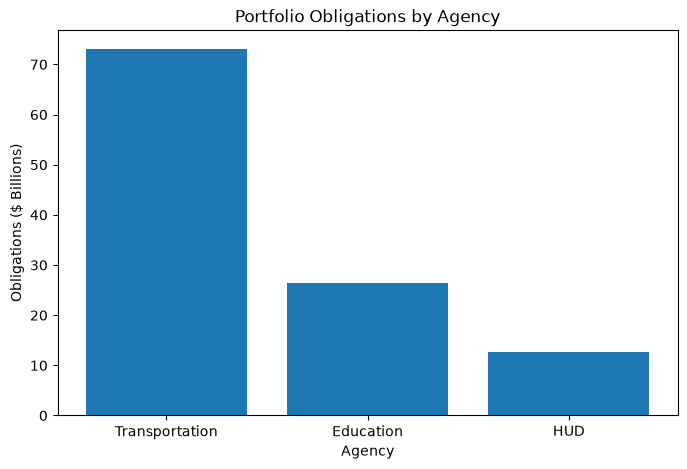

In [41]:
agency_chart = agency_summary.sort_values(
    "obligations_billions",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    agency_chart["agency"],
    agency_chart["obligations_billions"]
)

plt.title("Portfolio Obligations by Agency")
plt.xlabel("Agency")
plt.ylabel("Obligations ($ Billions)")

plt.show()

## 31. Analyze FY2026 Award Counts by Agency

I compare the number of FY2026 awards across the three agencies.


In [42]:
agency_awards = agency_summary.sort_values(
    "number_of_awards",
    ascending=False
)

agency_awards[[
    "agency",
    "number_of_awards"
]]


,agency,number_of_awards
2,Transportation,37581
1,HUD,14554
0,Education,7123


## 32. Visualize FY2026 Award Counts by Agency

I create a bar chart to compare the number of FY2026 awards across the three agencies.


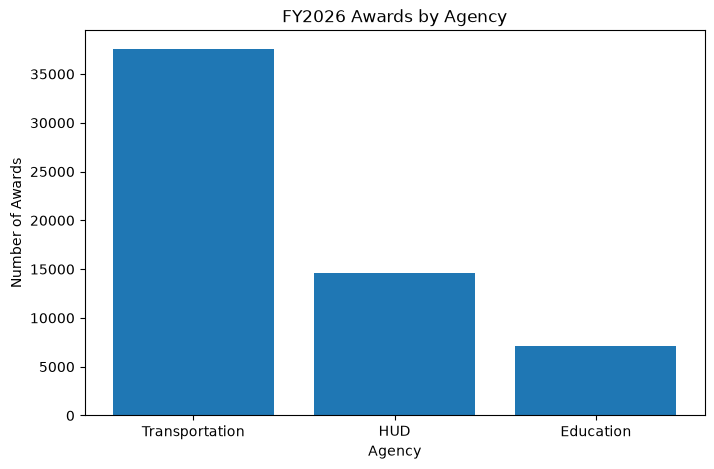

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    agency_awards["agency"],
    agency_awards["number_of_awards"]
)

plt.title("FY2026 Awards by Agency")
plt.xlabel("Agency")
plt.ylabel("Number of Awards")

plt.show()


## 33. Analyze Award Categories

I compare contracts and financial assistance based on the number of FY2026 awards and total obligated amount in the portfolio.


In [44]:
category_summary = awards.groupby("award_category").agg(
    number_of_awards=("award_unique_key", "count"),
    total_obligations=("total_obligated_amount", "sum")
).reset_index()

category_summary["obligations_billions"] = (
    category_summary["total_obligations"] / 1_000_000_000
)

category_summary[[
    "award_category",
    "number_of_awards",
    "obligations_billions"
]].round(2)

,award_category,number_of_awards,obligations_billions
0,Contract,6360,7.20
1,Financial Assistance,52898,104.89


## 34. Calculate Award Category Share

I calculate the percentage of FY2026 portfolio obligations represented by contracts and financial assistance.


In [45]:
category_summary["obligation_share"] = (
    category_summary["total_obligations"] /
    category_summary["total_obligations"].sum() * 100
)

category_summary[[
    "award_category",
    "number_of_awards",
    "obligations_billions",
    "obligation_share"
]].round(2)

,award_category,number_of_awards,obligations_billions,obligation_share
0,Contract,6360,7.20,6.42
1,Financial Assistance,52898,104.89,93.58


## 35. Analyze Recipient States

I group FY2026 awards by recipient state to examine the geographic distribution of obligations. The location represents the recipient's state and does not necessarily represent where the funded project or activity occurred.


In [46]:
state_summary = awards.groupby("recipient_state_name").agg(
    number_of_awards=("award_unique_key", "count"),
    total_obligations=("total_obligated_amount", "sum")
).reset_index()

state_summary["obligations_billions"] = (
    state_summary["total_obligations"] / 1_000_000_000
)

state_summary = state_summary.sort_values(
    "total_obligations",
    ascending=False
)

state_summary.head(10)[[
    "recipient_state_name",
    "number_of_awards",
    "obligations_billions"
]].round(2)

,recipient_state_name,number_of_awards,obligations_billions
6,CALIFORNIA,3191,11.77
54,TEXAS,3481,9.62
37,NEW YORK,2792,8.72
46,PENNSYLVANIA,2065,5.24
10,DISTRICT OF COLUMBIA,383,4.97
11,FLORIDA,2083,4.74
16,ILLINOIS,2494,4.22
41,OHIO,2318,3.76
58,VIRGINIA,2635,3.45
38,NORTH CAROLINA,1225,2.63


## 36. Visualize the Top 10 Recipient States

I visualize the ten recipient states with the largest cumulative obligated amounts in the FY2026 portfolio.


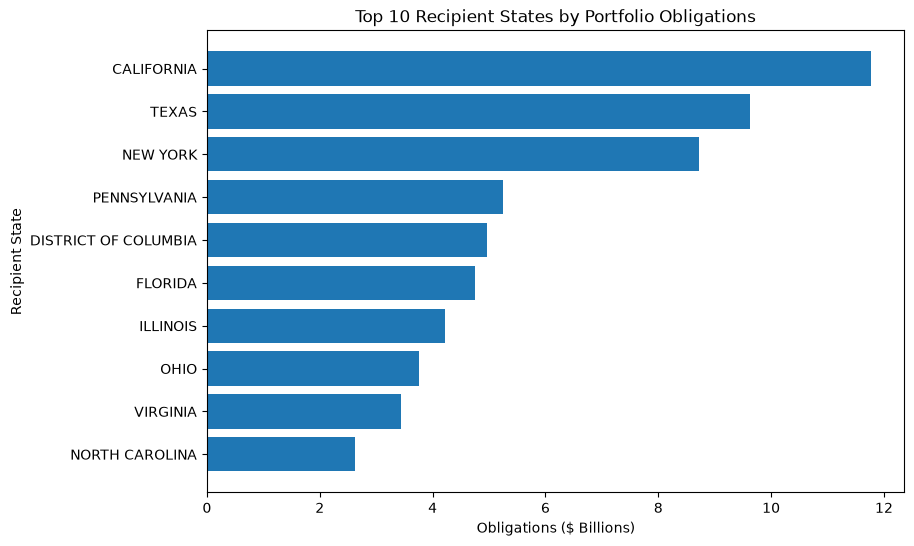

In [47]:
top_states = state_summary.head(10).sort_values(
    "obligations_billions"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_states["recipient_state_name"],
    top_states["obligations_billions"]
)

plt.title("Top 10 Recipient States by Portfolio Obligations")
plt.xlabel("Obligations ($ Billions)")
plt.ylabel("Recipient State")

plt.show()

## 37. Analyze Top Recipients

I identify the recipients associated with the largest cumulative obligated amounts in the FY2026 portfolio.


In [48]:
recipient_summary = awards.groupby("recipient_name").agg(
    number_of_awards=("award_unique_key", "count"),
    total_obligations=("total_obligated_amount", "sum")
).reset_index()

recipient_summary["obligations_billions"] = (
    recipient_summary["total_obligations"] / 1_000_000_000
)

recipient_summary = recipient_summary.sort_values(
    "total_obligations",
    ascending=False
)

recipient_summary.head(10)[[
    "recipient_name",
    "number_of_awards",
    "obligations_billions"
]].round(2)

,recipient_name,number_of_awards,obligations_billions
12030,TEXAS DEPARTMENT OF TRANSPORTATION,1454,4.65
4066,DEPARTMENT OF TRANSPORTATION CALIFORNIA,982,3.46
9031,NATIONAL RAILROAD PASSENGER CORPORATION,12,2.97
9916,PENNSYLVANIA DEPARTMENT OF TRANSPORTATION,1089,2.77
4070,DEPARTMENT OF TRANSPORTATION NEW YORK,1620,2.27
4029,DEPARTMENT OF EDUCATION CALIFORNIA,15,2.23
9551,OHIO DEPARTMENT OF TRANSPORTATION,1464,2.08
8551,METROPOLITAN TRANSPORTATION AUTHORITY,22,1.88
12685,TX EDUCATION AGENCY,15,1.74
9199,NEW YORK CITY HOUSING AUTHORITY,145,1.72


## 38. Calculate Recipient Concentration

I calculate the share of total FY2026 portfolio obligations associated with the ten largest recipients.


In [49]:
top_10_recipient_share = (
    recipient_summary.head(10)["total_obligations"].sum()
    / awards["total_obligated_amount"].sum()
    * 100
)

print(
    "Top 10 Recipient Share:",
    round(top_10_recipient_share, 2),
    "%"
)

Top 10 Recipient Share: 22.98 %


## 39. Analyze Major Programs

I identify the programs or activities associated with the largest obligated amounts in FY2026. Financial assistance awards are classified using Assistance Listing (CFDA) programs, while contracts are classified using NAICS industries.


In [50]:
program_summary = awards.groupby(
    ["award_category", "program_code", "program_name"]
).agg(
    number_of_awards=("award_unique_key", "count"),
    total_obligations=("total_obligated_amount", "sum")
).reset_index()

program_summary["obligations_billions"] = (
    program_summary["total_obligations"] / 1_000_000_000
)

program_summary = program_summary.sort_values(
    "total_obligations",
    ascending=False
)

program_summary.head(10)[[
    "award_category",
    "program_code",
    "program_name",
    "number_of_awards",
    "obligations_billions"
]].round(2)

,award_category,program_code,program_name,number_of_awards,obligations_billions
347,Financial Assistance,20.279,NATIONAL HIGHWAY PERFORMANCE PROGRAM (NHPP),3605,12.11
352,Financial Assistance,20.287,SURFACE TRANSPORTATION BLOCK GRANT PROGRAM,9776,9.70
429,Financial Assistance,84.010,TITLE I GRANTS TO LOCAL EDUCATIONAL AGENCIES,53,7.55
369,Financial Assistance,20.507,FEDERAL TRANSIT FORMULA GRANTS,713,5.43
433,Financial Assistance,84.027,SPECIAL EDUCATION GRANTS TO STATES,113,5.03
334,Financial Assistance,20.263,BRIDGE FORMULA PROGRAM,2675,4.40
440,Financial Assistance,84.126,REHABILITATION SERVICES VOCATIONAL REHABILITAT...,78,4.03
299,Financial Assistance,14.850,PUBLIC HOUSING OPERATING FUND,6409,3.60
389,Financial Assistance,20.525,STATE OF GOOD REPAIR GRANTS PROGRAM,58,3.20
306,Financial Assistance,14.872,PUBLIC HOUSING CAPITAL FUND,2771,3.18


## 40. Analyze Top Financial Assistance Programs

I separately examine FY2026 financial assistance programs because assistance awards use Assistance Listing (CFDA) classifications, while contracts use NAICS industry classifications.


In [51]:
assistance_programs = program_summary[
    program_summary["award_category"] == "Financial Assistance"
].head(10)

assistance_programs[[
    "program_code",
    "program_name",
    "number_of_awards",
    "obligations_billions"
]].round(2)

,program_code,program_name,number_of_awards,obligations_billions
347,20.279,NATIONAL HIGHWAY PERFORMANCE PROGRAM (NHPP),3605,12.11
352,20.287,SURFACE TRANSPORTATION BLOCK GRANT PROGRAM,9776,9.70
429,84.010,TITLE I GRANTS TO LOCAL EDUCATIONAL AGENCIES,53,7.55
369,20.507,FEDERAL TRANSIT FORMULA GRANTS,713,5.43
433,84.027,SPECIAL EDUCATION GRANTS TO STATES,113,5.03
334,20.263,BRIDGE FORMULA PROGRAM,2675,4.40
440,84.126,REHABILITATION SERVICES VOCATIONAL REHABILITAT...,78,4.03
299,14.850,PUBLIC HOUSING OPERATING FUND,6409,3.60
389,20.525,STATE OF GOOD REPAIR GRANTS PROGRAM,58,3.20
306,14.872,PUBLIC HOUSING CAPITAL FUND,2771,3.18


## 41. Analyze Top Contract Activities

I separately examine FY2026 contract activities using NAICS industry classifications.


In [52]:
contract_programs = program_summary[
    program_summary["award_category"] == "Contract"
].head(10)

contract_programs[[
    "program_code",
    "program_name",
    "number_of_awards",
    "obligations_billions"
]].round(2)

,program_code,program_name,number_of_awards,obligations_billions
96,334511.0,"SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...",122,0.88
14,237310.0,"HIGHWAY, STREET, AND BRIDGE CONSTRUCTION",111,0.74
187,522390.0,OTHER ACTIVITIES RELATED TO CREDIT INTERMEDIATION,5,0.71
154,483111.0,DEEP SEA FREIGHT TRANSPORTATION,532,0.60
211,541512.0,COMPUTER SYSTEMS DESIGN SERVICES,458,0.54
205,541330.0,ENGINEERING SERVICES,430,0.49
10,236220.0,COMMERCIAL AND INSTITUTIONAL BUILDING CONSTRUC...,136,0.44
86,334210.0,TELEPHONE APPARATUS MANUFACTURING,19,0.39
115,336411.0,AIRCRAFT MANUFACTURING,2,0.18
83,334111.0,ELECTRONIC COMPUTER MANUFACTURING,596,0.17


## 42. Check Negative and Zero Obligations

Federal award data can contain negative obligations due to deobligations or award adjustments. I identify negative and zero obligation records but retain them in the FY2026 dataset.


In [53]:
negative_obligations = (
    awards["total_obligated_amount"] < 0
).sum()

zero_obligations = (
    awards["total_obligated_amount"] == 0
).sum()

print("Negative obligation records:", negative_obligations)
print("Zero obligation records:", zero_obligations)

Negative obligation records: 378
Zero obligation records: 599


## 43. Check Outlay Coverage

I review the availability of outlay data in the FY2026 portfolio before using it in the analysis. Missing outlay values are not treated as zero.


In [54]:
print(
    "Awards with outlay data:",
    awards["total_outlayed_amount"].notna().sum()
)

print(
    "Awards missing outlay data:",
    awards["total_outlayed_amount"].isna().sum()
)

print(
    "Outlay coverage:",
    round(
        awards["total_outlayed_amount"].notna().mean() * 100,
        2
    ),
    "%"
)

Awards with outlay data: 46407
Awards missing outlay data: 12851
Outlay coverage: 78.31 %


## 44. Validate the Analysis Dataset

Before exporting the results, I perform a final check of the FY2026 dataset size, agencies, award categories, unique awards, and total obligations.


In [55]:
print("Total awards:", len(awards))
print("Unique awards:", awards["award_unique_key"].nunique())
print("Fiscal years:", sorted(awards["fiscal_year"].unique()))
print("Agencies:", awards["agency"].unique())
print("Award categories:", awards["award_category"].unique())

print(
    "Total obligations ($ billions):",
    round(
        awards["total_obligated_amount"].sum()
        / 1_000_000_000,
        2
    )
)

Total awards: 59258
Unique awards: 59258
Fiscal years: [np.int64(2026)]
Agencies: <StringArray>
['Transportation', 'Education', 'HUD']
Length: 3, dtype: str
Award categories: <StringArray>
['Contract', 'Financial Assistance']
Length: 2, dtype: str
Total obligations ($ billions): 112.09


## 45. Check FY2026 Coverage by Award Category

I review the number of FY2026 contract and financial assistance awards included in the final dataset.


In [56]:
coverage_check = awards.groupby(
    "award_category"
).size()

coverage_check


award_category
Contract                 6360
Financial Assistance    52898
dtype: int64

## 46. Check FY2026 Source Records

I confirm the number of FY2026 records in each original source dataset.


In [57]:
contracts[
    contracts["award_base_action_date_fiscal_year"] == 2026
].shape[0]


6360

In [58]:
assistance[
    assistance["award_base_action_date_fiscal_year"] == 2026
].shape[0]


52898

## 47. Check the FY2026 Award Date Range

I check the earliest and latest base action dates for FY2026 records in both source datasets.


In [59]:
contracts_2026_dates = contracts[
    contracts["award_base_action_date_fiscal_year"] == 2026
]

assistance_2026_dates = assistance[
    assistance["award_base_action_date_fiscal_year"] == 2026
]

print(
    "Contracts:",
    contracts_2026_dates["award_base_action_date"].min(),
    "to",
    contracts_2026_dates["award_base_action_date"].max()
)

print(
    "Financial Assistance:",
    assistance_2026_dates["award_base_action_date"].min(),
    "to",
    assistance_2026_dates["award_base_action_date"].max()
)


Contracts: 2025-10-01 to 2026-09-15
Financial Assistance: 2025-10-16 to 2026-09-18


## 48. Final Data Validation

Before exporting the results, I perform a final check of the FY2026 dataset. I verify the number of awards, unique award IDs, agencies, award categories, and total obligations.

In [60]:
print("Total Awards:", len(awards))

print(
    "Unique Awards:",
    awards["award_unique_key"].nunique()
)

print("\nAwards by Agency:")
print(awards["agency"].value_counts())

print("\nAwards by Category:")
print(awards["award_category"].value_counts())

print(
    "\nTotal Obligations ($ Billions):",
    round(
        awards["total_obligated_amount"].sum()
        / 1_000_000_000,
        2
    )
)

Total Awards: 59258
Unique Awards: 59258

Awards by Agency:
agency
Transportation    37581
HUD               14554
Education          7123
Name: count, dtype: int64

Awards by Category:
award_category
Financial Assistance    52898
Contract                 6360
Name: count, dtype: int64

Total Obligations ($ Billions): 112.09


## 49. Create Final Summary

I create a final summary of the FY2026 federal awards portfolio. These measures will also be used later in the Excel dashboard.

In [61]:
final_summary = pd.DataFrame({
    "Measure": [
        "Total Awards",
        "Total Obligations ($ Billions)",
        "Contract Awards",
        "Financial Assistance Awards"
    ],
    "Value": [
        len(awards),
        round(
            awards["total_obligated_amount"].sum()
            / 1_000_000_000,
            2
        ),
        (awards["award_category"] == "Contract").sum(),
        (awards["award_category"] == "Financial Assistance").sum()
    ]
})

final_summary

,Measure,Value
0,Total Awards,59258.00
1,Total Obligations ($ Billions),112.09
2,Contract Awards,6360.00
3,Financial Assistance Awards,52898.00


## 50. Export the Cleaned Dataset

I export the cleaned FY2026 award-level dataset so that it can be used for additional analysis and documentation.

In [ ]:
awards.to_csv(
    "FY2026_Federal_Awards_Cleaned.csv",
    index=False
)
print("Cleaned dataset exported.")

Cleaned dataset exported.


In [63]:
FY2026 = pd.read_csv("FY2026_Federal_Awards_Cleaned.csv")
print("Rows:", FY2026.shape[0])
print("Columns:", FY2026.shape[1])

Rows: 59258
Columns: 13
